<div style="
    background-color: pink;
    padding: 60px 20px;
    margin: 40px auto;
    border-radius: 18px;
    box-shadow: 0 3px 6px rgba(0, 0, 0, 0.3);
    border: 4px solid #ffffff;
    text-align: center;
    width: 95%;
    box-sizing: border-box;
    overflow: visible;
">
    <h1 style="
        color: white !important;
        font-family: 'Arial Black', Arial, sans-serif;
        font-size: 50px;
        font-weight: 900;
        margin: 0 !important;
        padding: 0 !important;
        line-height: 1 !important;
        text-shadow: 2px 2px 5px rgba(0,0,0,0.7);
        display: block;
    ">
        Cosmetics Data Analysis 
    </h1>
</div>

Cosmetics sold at Sephora & Ulta

<img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.pngarts.com%2Ffiles%2F5%2FCosmetics-Transparent-Background-PNG.png&f=1&nofb=1&ipt=18a61221e29a05ae17de289d3d01108412210d013c0ec7eff340d5c5a1fc8f20"
     style="display: block; margin-left: auto; margin-right: auto;"
     alt="Study Header Image">

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Import Libraries</b></div>

In [1]:
import numpy as np
import pandas as pd
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt
pink_palette = sns.color_palette(["#FF69B4", "#FF1493", "#DB7093", "#FFC0CB", "#FFB6C1"])
sns.set_palette(pink_palette)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Read and Examine Dataset</b></div>

In [2]:
df = pd.read_csv('/kaggle/input/cosmetics-datasets/cosmetics.csv')
df.head()

,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1


In [3]:
print("The dataset's shape is",df.shape[0], "rows and", df.shape[1], "columns.")

The dataset's shape is 1472 rows and 11 columns.


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Unique values</b></div>

In [4]:
print("Unique values")
print(df.nunique(),'\n')

Unique values
Label             6
Brand           116
Name           1472
Price           146
Rank             29
Ingredients    1334
Combination       2
Dry               2
Normal            2
Oily              2
Sensitive         2
dtype: int64 



# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Number of Products per Category</b></div>

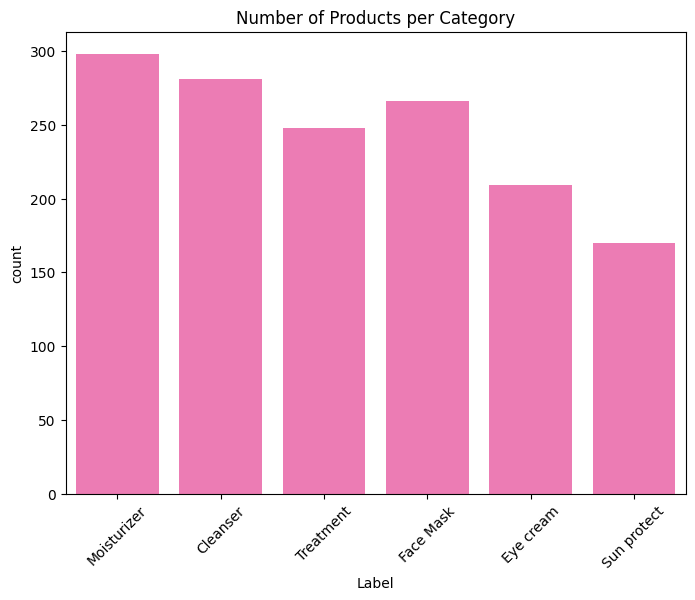

In [5]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Label')
plt.title("Number of Products per Category")
plt.xticks(rotation=45)
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Price Distribution</b></div>

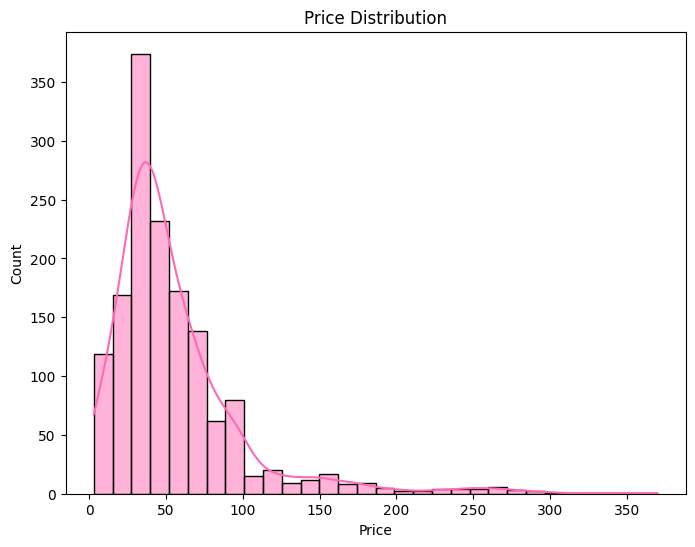

In [6]:
plt.figure(figsize=(8,6))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Price by Product Category</b></div>

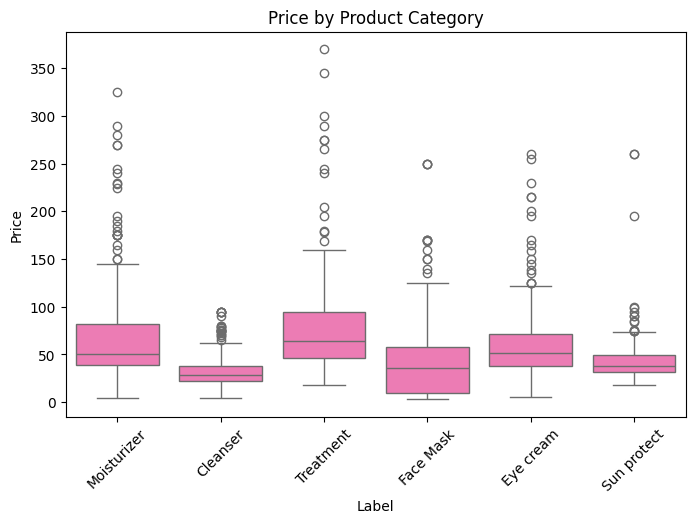

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Label', y='Price')
plt.title("Price by Product Category")
plt.xticks(rotation=45)
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Product Rating Distribution</b></div>

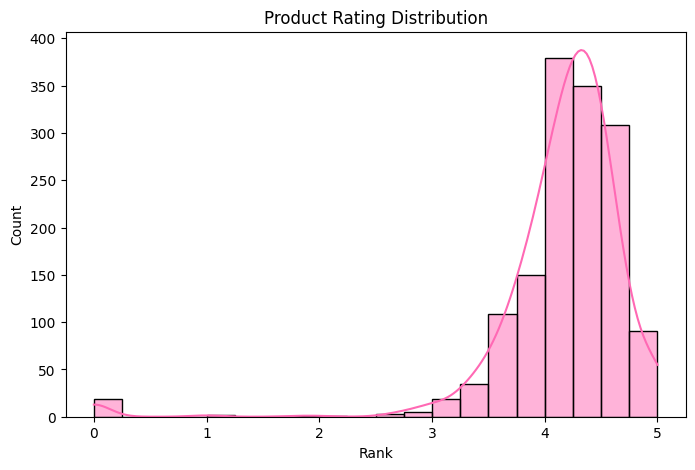

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rank'], bins=20, kde=True)
plt.title("Product Rating Distribution")
plt.xlabel("Rank")
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Price vs Rating</b></div>

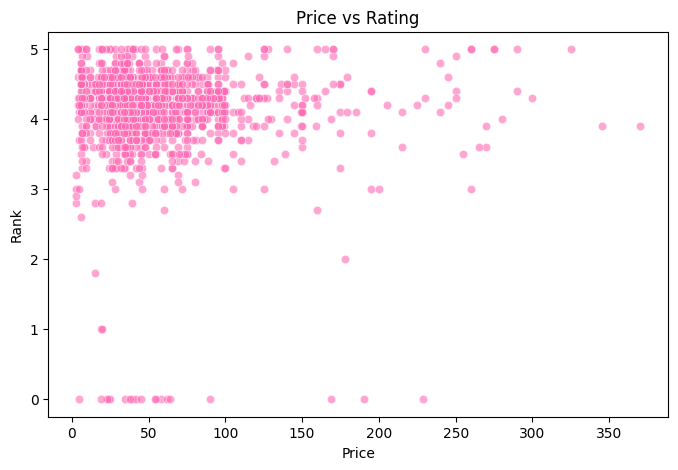

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Price', y='Rank', alpha=0.6)
plt.title("Price vs Rating")
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Top 10 Brands by Number of Products</b></div>

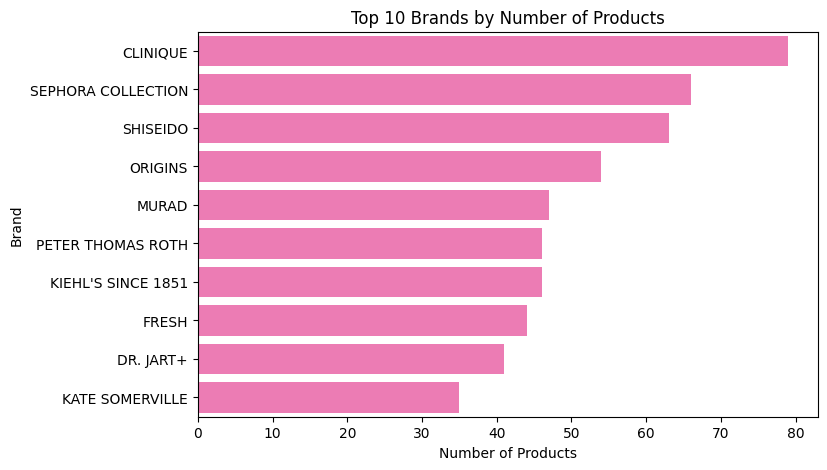

In [10]:
top_brands = df['Brand'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title("Top 10 Brands by Number of Products")
plt.xlabel("Number of Products")
plt.show()


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Skin Type Compatibility Distribution</b></div>

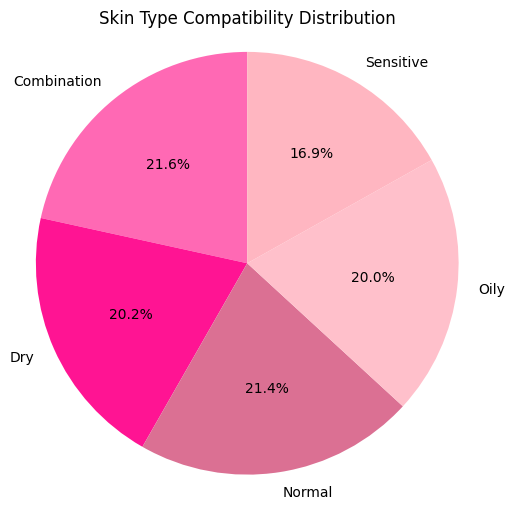

In [11]:
skin_types = ['Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']

skin_type_counts = df[skin_types].sum()

plt.figure(figsize=(6, 6))
plt.pie(
    skin_type_counts,
    labels=skin_type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Skin Type Compatibility Distribution")
plt.axis('equal')
plt.show()


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Skin Type Compatibility by Product Category</b></div>

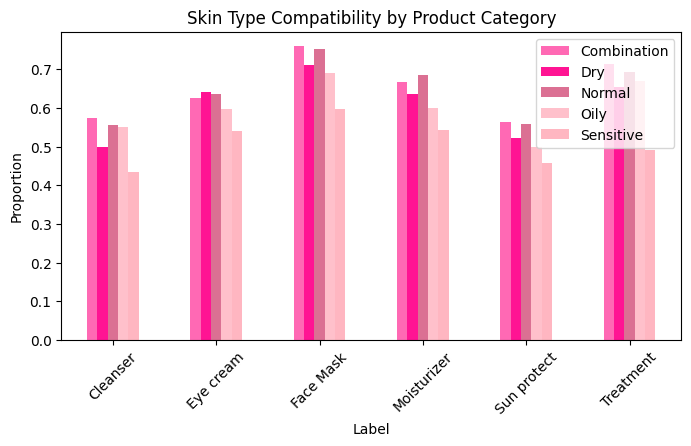

In [12]:
df.groupby('Label')[skin_types].mean().plot(
    kind='bar',
    figsize=(8,4)
)
plt.title("Skin Type Compatibility by Product Category")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Number of Ingredients per Product</b></div>

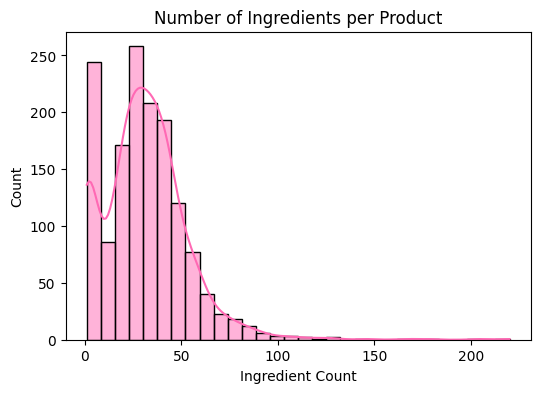

In [13]:
df['Ingredient_Count'] = df['Ingredients'].str.split(',').apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df['Ingredient_Count'], bins=30, kde=True)
plt.title("Number of Ingredients per Product")
plt.xlabel("Ingredient Count")
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Top 12 Most Used Ingredients (Overall)</b></div>

Number of ingredients 45816


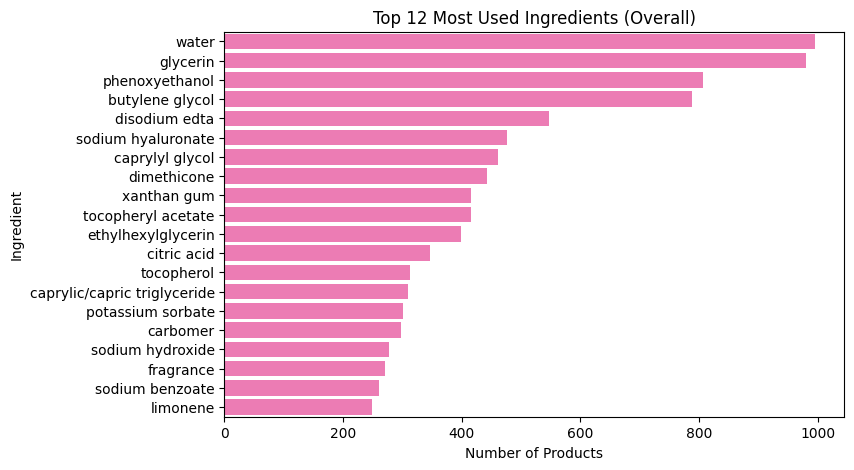

In [14]:
all_ingredients = (
    df['Ingredients']
    .str.split(',')
    .explode()
    .str.strip()
    .str.lower()
)

print('Number of ingredients', len(all_ingredients))

ingredient_counts = all_ingredients.value_counts().head(20)

plt.figure(figsize=(8,5))
sns.barplot(
    x=ingredient_counts.values,
    y=ingredient_counts.index
)
plt.title("Top 12 Most Used Ingredients (Overall)")
plt.xlabel("Number of Products")
plt.ylabel("Ingredient")
plt.show()


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Top 12 Ingredients for Each Skin Type</b></div>

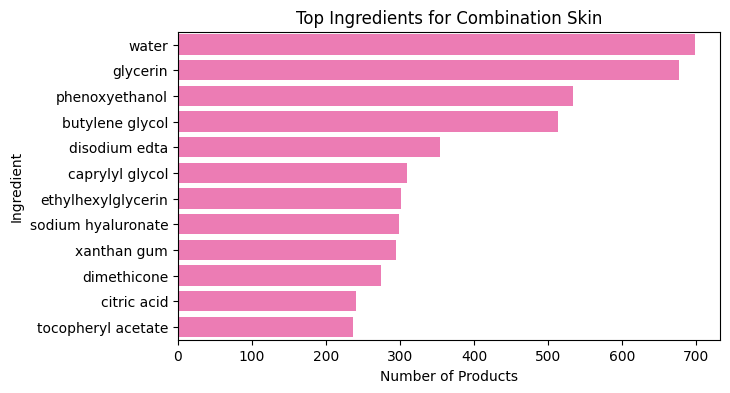

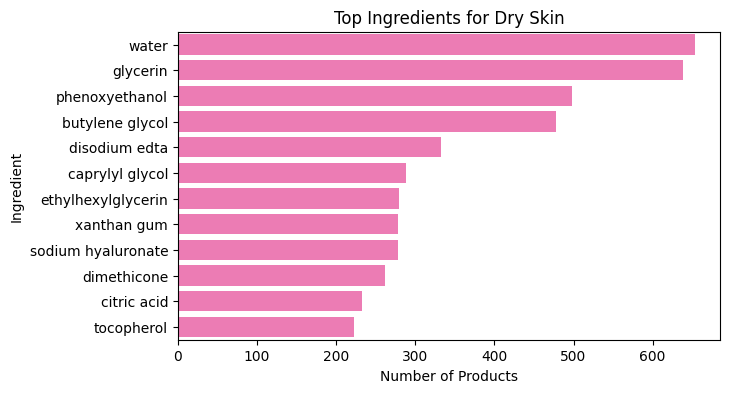

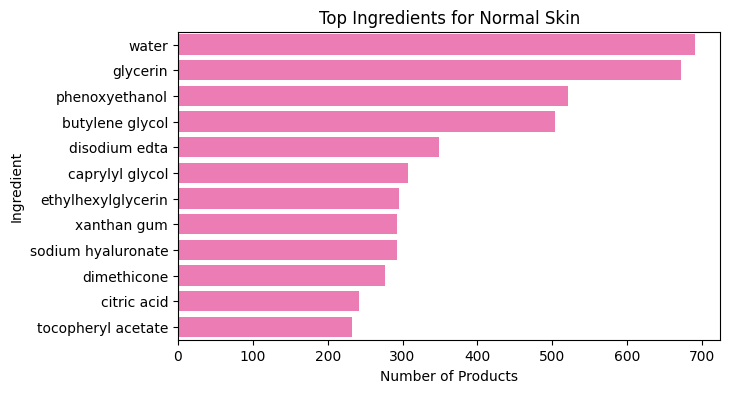

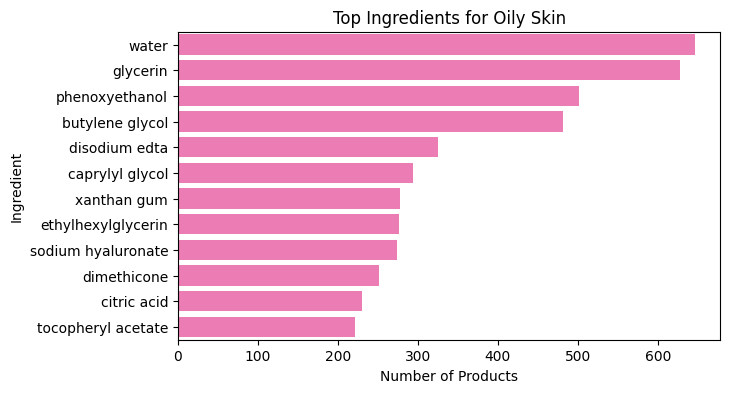

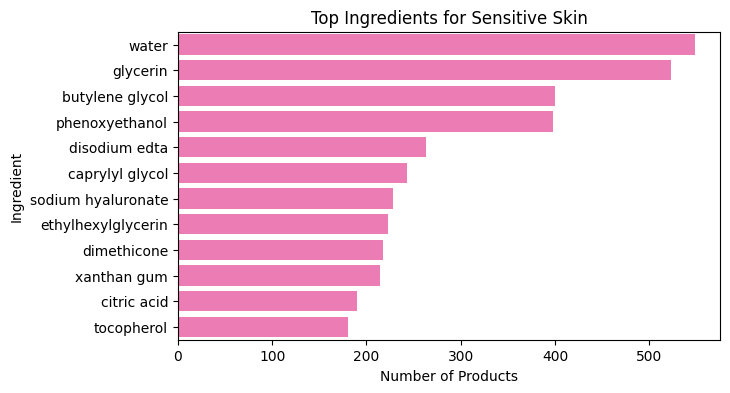

In [15]:
def top_ingredients_by_skin_type(df, skin_type, top_n=12):
    subset = df[df[skin_type] == 1]

    ingredients = (
        subset['Ingredients']
        .str.split(',')
        .explode()
        .str.strip()
        .str.lower()
    )

    return ingredients.value_counts().head(top_n)

skin_types = ['Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']

top_ingredients_skin = {
    skin: top_ingredients_by_skin_type(df, skin)
    for skin in skin_types
}

for skin, counts in top_ingredients_skin.items():
    plt.figure(figsize=(7,4))
    sns.barplot(
        x=counts.values,
        y=counts.index
    )
    plt.title(f"Top Ingredients for {skin} Skin")
    plt.xlabel("Number of Products")
    plt.ylabel("Ingredient")
    plt.show()

In [16]:
df['Ingredient_Count'] = df['Ingredients'].str.split(',').apply(len)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Top 10 Products with the Least Ingredients</b></div>

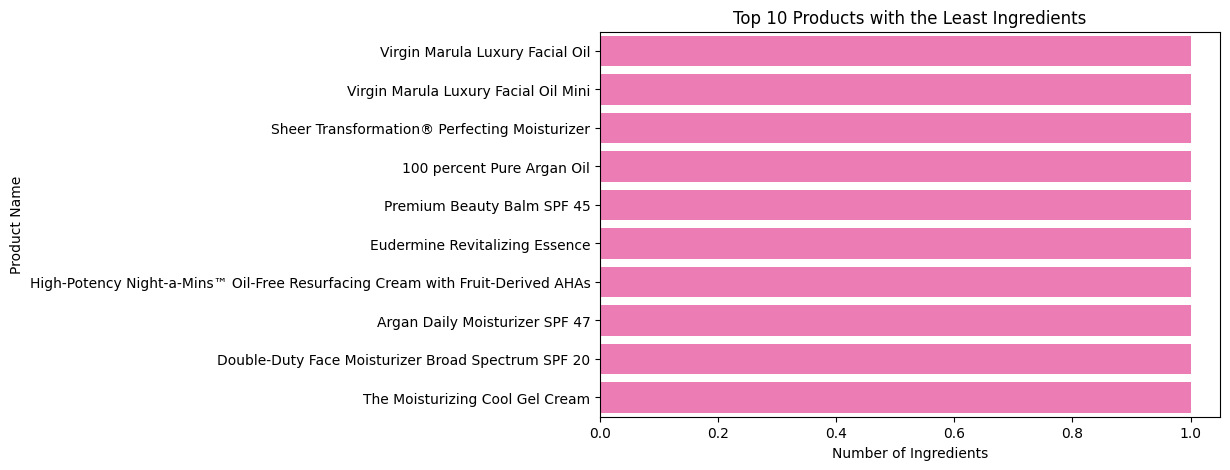

In [17]:
least_ingredients = df.nsmallest(10, 'Ingredient_Count')
plt.figure(figsize=(8,5))
sns.barplot(
    x='Ingredient_Count',
    y='Name',
    data=least_ingredients
)
plt.title("Top 10 Products with the Least Ingredients")
plt.xlabel("Number of Ingredients")
plt.ylabel("Product Name")
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Top 10 Products with the Most Ingredients</b></div>

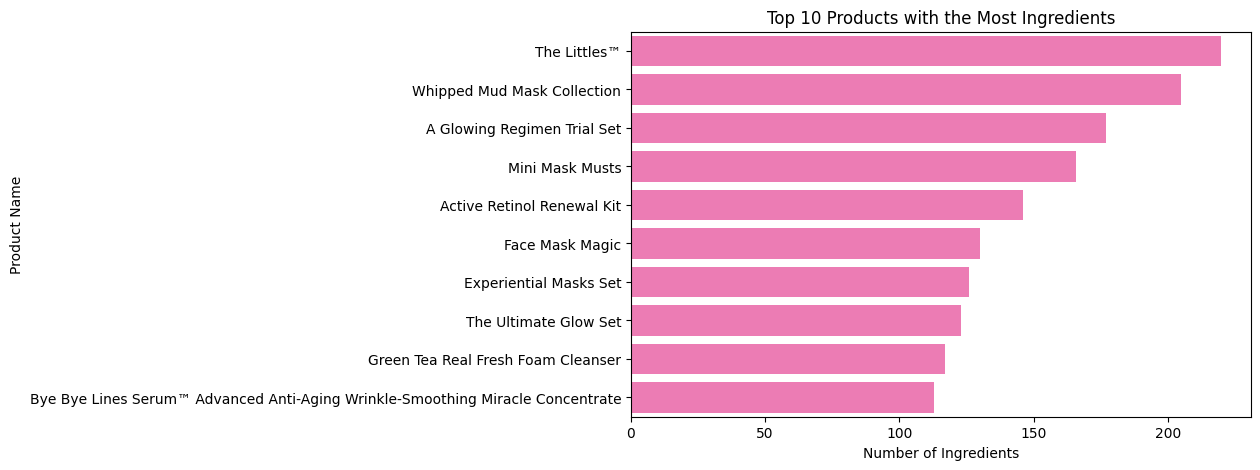

In [18]:
most_ingredients = df.nlargest(10, 'Ingredient_Count')
plt.figure(figsize=(8,5))
sns.barplot(
    x='Ingredient_Count',
    y='Name',
    data=most_ingredients
)
plt.title("Top 10 Products with the Most Ingredients")
plt.xlabel("Number of Ingredients")
plt.ylabel("Product Name")
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background-color:pink; overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Distribution of Number of Ingredients per Product</b></div>

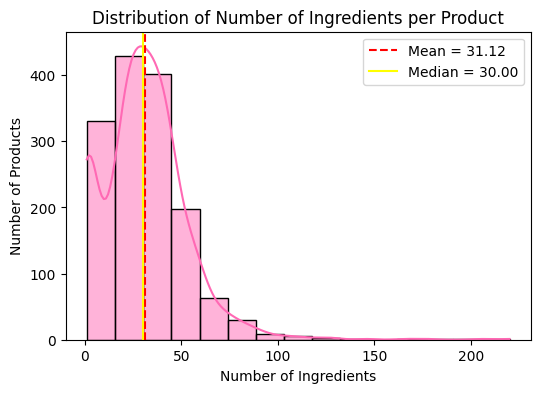

In [19]:
df['Ingredient_Count'] = df['Ingredients'].str.split(',').apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df['Ingredient_Count'], bins=15, kde=True)
plt.axvline(df['Ingredient_Count'].mean(), color='red', linestyle='--', label=f'Mean = {df['Ingredient_Count'].mean():.2f}')
plt.axvline(df['Ingredient_Count'].median(), color='yellow', linestyle='-', label=f'Median = {df['Ingredient_Count'].median():.2f}')
plt.title("Distribution of Number of Ingredients per Product")
plt.xlabel("Number of Ingredients")
plt.ylabel("Number of Products")
plt.legend()
plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
<b>Thank you for reading this far ! If you find this notebook useful, please consider giving it an upvote.😊</b><br>
</div>